# Pre-Draft LoL Match Prediction — Research Notebook

This notebook is the interactive version of `run_pipeline.py`. Each section corresponds to a pipeline stage and can be run independently (results are cached to `./cache/` as parquet files).

**Stages:**
1. Setup & configuration
2. Load raw data
3. Elo computation
4. Feature engineering
5. Dataset construction
6. Train/validation/holdout split
7. Rolling cross-validation
8. Hyperparameter tuning
9. Final holdout evaluation
10. Feature importance & ablation
11. Leakage checklist

---
## 0. Setup & Configuration

In [1]:
import warnings
import logging
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-7s  %(message)s',
    datefmt='%H:%M:%S',
)

ROOT = Path('.').resolve()
CACHE_DIR  = ROOT / 'cache'
OUTPUT_DIR = ROOT / 'outputs'
CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('Root:', ROOT)

Root: /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model


In [2]:
# ── Key knobs you may want to change ──────────────────────────────────────────

# Years to include (all available: 2014–2026)
# For quick iterations, use a subset like [2022, 2023, 2024, 2025, 2026]
USE_YEARS = list(range(2020, 2027))   # None = all years

# Rolling CV parameters
TRAIN_DAYS  = 180
VAL_DAYS    = 14
STRIDE_DAYS = 14

# Tuning: number of random param combos per model, and how many recent folds to use
N_TUNE_ITER       = 20
TUNE_LAST_N_FOLDS = 30

# Set True to re-run a stage even if its cache exists
FORCE_RELOAD    = True
FORCE_ELO       = True
FORCE_FEATURES  = True
FORCE_DATASET   = True
FORCE_SPLIT     = True
FORCE_CV        = True
FORCE_TUNE      = True
FORCE_ABLATION  = True

In [3]:
# ── Cache helpers ──────────────────────────────────────────────────────────────
# Pickle format: avoids ArrowDtype / arrow.py_extension_type issues across kernels.

def cache_save(df: pd.DataFrame, name: str) -> None:
    p = CACHE_DIR / f"{name}.pkl"
    df.to_pickle(p)
    print(f"  Cached {name} ({len(df):,} rows) → {p.name}")

def cache_load(name: str) -> pd.DataFrame | None:
    p = CACHE_DIR / f"{name}.pkl"
    if p.exists():
        df = pd.read_pickle(p)
        print(f"  Loaded {name} from cache ({len(df):,} rows)")
        return df
    return None

def folds_save(folds, name="folds"):
    with open(CACHE_DIR / f"{name}.pkl", "wb") as f:
        pickle.dump(folds, f)
    print(f"  Cached {len(folds)} folds")

def folds_load(name="folds"):
    p = CACHE_DIR / f"{name}.pkl"
    if p.exists():
        with open(p, "rb") as f:
            folds = pickle.load(f)
        print(f"  Loaded {len(folds)} folds from cache")
        return folds
    return None

---
## 1. Load Raw Data

Loads all yearly Oracle's Elixir CSVs, filters to team-level rows (`position == 'team'`), parses dates, and builds the opponent mapping (`opp_teamid`).  
No features are computed here — just raw data cleaning.

In [4]:
from pipeline.load_data import load_all

team_df   = None if FORCE_RELOAD else cache_load('team_df')
player_df = None if FORCE_RELOAD else cache_load('player_df')

if team_df is None or player_df is None:
    t0 = time.time()
    team_df, player_df = load_all(use_years=USE_YEARS)
    print(f'  Loaded in {time.time()-t0:.1f}s')
    cache_save(team_df,   'team_df')
    cache_save(player_df, 'player_df')

print(f'Team rows:        {len(team_df):,}')
print(f'Player rows:      {len(player_df):,}')
print(f'Unique matches:   {team_df["gameid"].nunique():,}')
print(f'Date range:       {team_df["date"].min().date()} – {team_df["date"].max().date()}')
print(f'Leagues:          {team_df["league"].nunique()}')

17:33:50  INFO     Loaded 820788 raw rows from 7 files
17:33:54  WARNING  opp_teamid missing for 2121 rows
17:33:54  INFO     Team rows: 136798  |  Player rows: 683990  |  Unique matches: 68399


  Loaded in 13.1s
  Cached team_df (136,798 rows) → team_df.pkl
  Cached player_df (683,990 rows) → player_df.pkl
Team rows:        136,798
Player rows:      683,990
Unique matches:   68,399
Date range:       2020-01-03 – 2026-04-03
Leagues:          106


,date,league,teamname,side,result,opp_teamid
0,2020-01-03 07:33:26+00:00,KeSPA,Liiv SANDBOX,Blue,1,oe:team:ce499dea30cfce118f4fe85da0227e8
1,2020-01-03 07:33:26+00:00,KeSPA,T1,Red,0,oe:team:c75f1f337fc5867914749d438a4871d
2,2020-01-03 09:00:58+00:00,KeSPA,T1,Blue,0,oe:team:c75f1f337fc5867914749d438a4871d
3,2020-01-03 09:00:58+00:00,KeSPA,Liiv SANDBOX,Red,1,oe:team:ce499dea30cfce118f4fe85da0227e8
4,2020-01-03 10:05:17+00:00,KeSPA,T1,Blue,1,oe:team:c75f1f337fc5867914749d438a4871d
5,2020-01-03 10:05:17+00:00,KeSPA,Liiv SANDBOX,Red,0,oe:team:ce499dea30cfce118f4fe85da0227e8


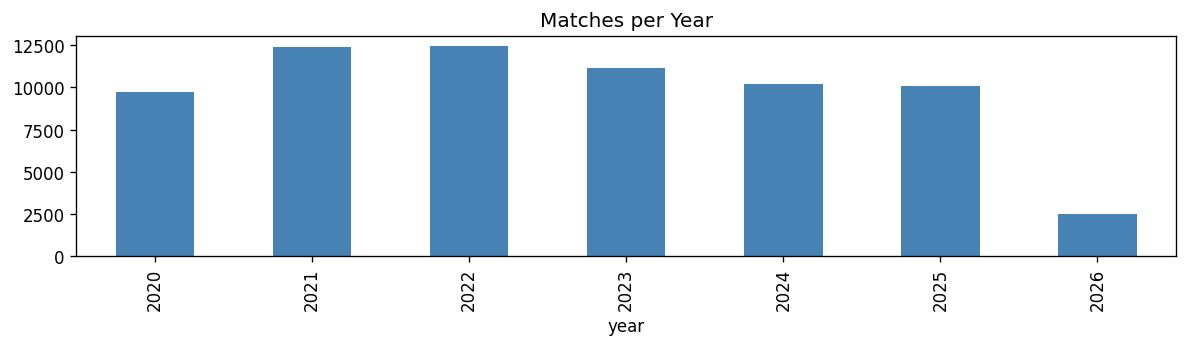

In [5]:
# Quick data overview
display(team_df[['date', 'league', 'teamname', 'side', 'result', 'opp_teamid']].head(6))

# Matches per year
team_df.assign(year=team_df['date'].dt.year).groupby('year')['gameid'].nunique() \
    .rename('matches').plot(kind='bar', figsize=(10, 3), title='Matches per Year', color='steelblue')
plt.tight_layout()
plt.show()

---
## 2. Elo Computation

Processes all matches in strict chronological order.  
**Leakage rule:** `elo_team` and `elo_opp` are recorded *before* the match result updates the ratings.  
K = 20, init = 1500.

In [6]:
from pipeline.elo import compute_elo

elo_df = None if FORCE_ELO else cache_load('elo_df')

if elo_df is None:
    t0 = time.time()
    elo_df = compute_elo(team_df)
    print(f'  Elo computed in {time.time()-t0:.1f}s')
    cache_save(elo_df, 'elo_df')

print(f'Elo range: [{elo_df["elo_team"].min():.0f}, {elo_df["elo_team"].max():.0f}]')

17:34:00  INFO     Elo computed. Range: [1163, 1978]  Decayed: [1167, 1977]


  Elo computed in 5.0s
  Cached elo_df (136,798 rows) → elo_df.pkl
Elo range: [1163, 1978]


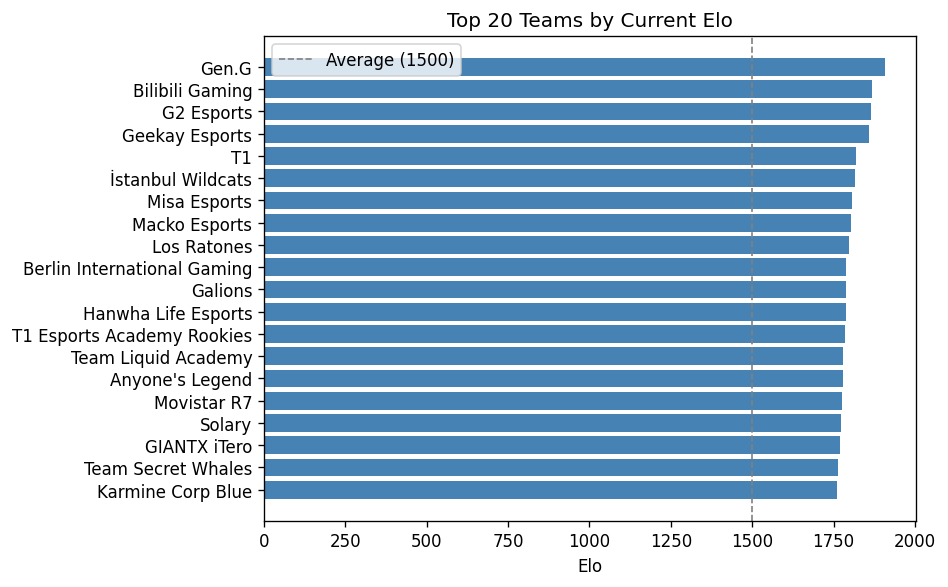

In [7]:
# Top 20 teams by current Elo (most recent entry per team)
latest_elo = (
    elo_df.sort_values('date')
    .groupby('teamname')[['elo_team', 'date']].last()
    .sort_values('elo_team', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(latest_elo.index[::-1], latest_elo['elo_team'][::-1], color='steelblue')
ax.axvline(1500, color='gray', ls='--', lw=1, label='Average (1500)')
ax.set_xlabel('Elo')
ax.set_title('Top 20 Teams by Current Elo')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
from pipeline.roster_features import compute_roster_features

# ── Roster feature engineering ─────────────────────────────────────────────
# Adds roster_overlap and games_since_roster_change to elo_df.
# Must run before compute_features() which computes rolling stats.

elo_roster_df = None if FORCE_ELO else cache_load('elo_roster_df')

if elo_roster_df is None:
    elo_roster_df = compute_roster_features(elo_df, player_df)
    cache_save(elo_roster_df, 'elo_roster_df')

n_changes = (elo_roster_df['roster_overlap'] < 1.0).sum()
print(f'Roster changes detected: {n_changes:,} ({n_changes/len(elo_roster_df)*100:.1f}% of games)')
print()
# Show distribution of roster overlap
print('Roster overlap distribution:')
display(elo_roster_df['roster_overlap'].value_counts(normalize=True).sort_index().round(3).to_frame())

Roster features ... done (4.5s) — 15,104 roster changes detected (11.0% of games)
  Cached elo_roster_df (136,798 rows) → elo_roster_df.pkl
Roster changes detected: 15,104 (11.0% of games)

Roster overlap distribution:


,proportion
roster_overlap,
0.0,0.009
0.2,0.006
0.4,0.007
0.6,0.017
0.8,0.071
1.0,0.889
1.8,0.000
2.0,0.000


---
## 3. Feature Engineering

Computes rolling features from each team's prior matches only.
Input: `elo_roster_df` (Elo + roster stability features already attached).

| Group | Features |
|---|---|
| A | Elo ratings (standard + time-decayed) |
| B | Recent form: win rates, EWMA, schedule strength, overperformance |
| C | Early-game: gold/XP diff means, std, threshold features |
| D | Conversion: lead → win rate, comeback rate |
| E | Objective control: dragon/baron/tower share |
| F | Style: pace, vision, economy (optional) |
| G | Side history: Blue/Red win rates vs patch |
| H | Patch adaptation: shrunk patch WR (optional) |
| J | Schedule: rest days, workload, playoffs |
| P | **Head-to-head**: prior H2H win rate vs this opponent (shrunk) |
| R | **Roster stability**: overlap with previous game, games since change |
| K | Interaction terms (optional) |


In [9]:
from pipeline.features import compute_features, get_feature_cols

feat_df = None if FORCE_FEATURES else cache_load('feat_df')

if feat_df is None:
    t0 = time.time()
    feat_df = compute_features(elo_roster_df)   # uses elo_roster_df (has H2H + roster cols)
    print(f'  Features computed in {time.time()-t0:.1f}s')
    cache_save(feat_df, 'feat_df')

base_fcols = get_feature_cols(feat_df)
print(f'Base feature columns: {len(base_fcols)}')
print('Sample:', base_fcols[:8])
# Show new features
new_feats = [c for c in base_fcols if any(c.startswith(p) for p in ['h2h_', 'roster_', 'games_since'])]
print('New H2H + roster features:', new_feats)

Feature engineering — 136,798 rows
  B  recent form ... done (1.2s)
  C  early-game (means + thresholds) ... done (3.5s)
  D  conversion/closing ... done (1.1s)
  E  objective control ... done (1.5s)
  F  style ... done (0.6s)
  G  side history ... done (0.5s)
  H  patch adaptation ... done (7.7s)
  J  schedule/context ... done (1.8s)
  P  head-to-head ... done (5.2s)
  K  interactions ... done (0.0s)
Feature engineering complete — 98 feature cols in 22.9s


17:34:27  INFO     Feature engineering complete. 98 engineered feature cols.


  Features computed in 23.0s
  Cached feat_df (136,798 rows) → feat_df.pkl
Base feature columns: 98
Sample: ['elo_team', 'elo_opp', 'elo_diff', 'elo_expected', 'elo_decayed_team', 'elo_decayed_opp', 'elo_decayed_diff', 'elo_league_rel']
New H2H + roster features: ['roster_overlap', 'games_since_roster_change', 'h2h_wr', 'h2h_n_games']


In [10]:
# Feature completeness: fraction of non-null values per feature
completeness = feat_df[base_fcols].notna().mean().sort_values()
sparse = completeness[completeness < 0.5]
print(f'Features with <50% non-null: {len(sparse)}')
if not sparse.empty:
    print(sparse.to_string())

Features with <50% non-null: 0


---
## 4. Dataset Construction

For each row (team A in match M):
- Team features = team A's rolling history (already in `feat_df`)
- `opp_*` features = team B's rolling history (merged from team B's own row)
- `diff_*` = team A feature − team B feature

**No leakage:** team B's features are built from B's own prior matches, independently of match M.

In [11]:
from pipeline.dataset import build_dataset, get_model_cols

ds_df = None if FORCE_DATASET else cache_load('dataset_df')

if ds_df is None:
    t0 = time.time()
    ds_df = build_dataset(feat_df)
    print(f'  Dataset built in {time.time()-t0:.1f}s')
    cache_save(ds_df, 'dataset_df')

num_cols, cat_cols = get_model_cols(ds_df)
print(f'Dataset shape:     {ds_df.shape}')
print(f'Numeric features:  {len(num_cols)}')
print(f'Categorical:       {cat_cols}')
print(f'Target win rate:   {ds_df["result"].mean():.4f}  (expect ~0.5)')

17:34:27  INFO     Merging opponent features for 98 feature columns
17:34:27  INFO     Dropped 6 symmetric opp_ columns
17:34:27  INFO     Added 85 diff_ columns
17:34:27  INFO     Dataset built: 137488 rows, 275 feature cols (team + opp + diff)


  Dataset built in 0.1s
  Cached dataset_df (137,488 rows) → dataset_df.pkl
Dataset shape:     (137488, 289)
Numeric features:  275
Categorical:       ['league', 'split', 'side', 'patch']
Target win rate:   0.4999  (expect ~0.5)


In [12]:
# Quick leakage sanity check
forbidden_patterns = ['champion', 'pick1', 'ban1', 'firstPick', 'elo_overperf']
leaked = [c for c in num_cols if any(p in c for p in forbidden_patterns)]
print('Forbidden cols in feature matrix:', leaked if leaked else '✓ NONE – clean')

# Check elo_overperf not included directly
direct_overperf = [c for c in num_cols if c.replace('opp_','').replace('diff_','') == 'elo_overperf']
print('Direct elo_overperf in features:', direct_overperf if direct_overperf else '✓ NONE – clean (only rolled versions allowed)')

Forbidden cols in feature matrix: ✓ NONE – clean
Direct elo_overperf in features: ✓ NONE – clean (only rolled versions allowed)


---
## 5. Train / Validation / Holdout Split

- **Holdout (20%)** = most recent 20% of matches by date. Locked away until Stage 9.
- **Development (80%)** = used for CV and tuning.
- **Rolling CV** on dev set: train=180d, val=14d, stride=14d.

Both rows of each match always land in the same split (date-based gameid assignment).

In [13]:
from pipeline.validation import dev_holdout_split, rolling_folds, check_fold_leakage, describe_folds

dev_df  = None if FORCE_SPLIT else cache_load('dev_df')
hold_df = None if FORCE_SPLIT else cache_load('hold_df')
folds   = None if FORCE_SPLIT else folds_load()

if dev_df is None or hold_df is None or folds is None:
    dev_df, hold_df = dev_holdout_split(ds_df)
    folds = rolling_folds(dev_df, TRAIN_DAYS, VAL_DAYS, STRIDE_DAYS)
    check_fold_leakage(dev_df, folds)
    cache_save(dev_df,  'dev_df')
    cache_save(hold_df, 'hold_df')
    folds_save(folds)

print(f'Dev rows:     {len(dev_df):,}  ({dev_df["gameid"].nunique():,} matches)')
print(f'Holdout rows: {len(hold_df):,}  ({hold_df["gameid"].nunique():,} matches)')
print(f'Rolling folds: {len(folds)}')
print(f'  Train window: {TRAIN_DAYS}d')
print(f'  Val window:   {VAL_DAYS}d')
print(f'  Stride:       {STRIDE_DAYS}d')

17:34:28  INFO     Split: dev=109710 rows (54719 matches) up to 2024-09-18 | holdout=27778 rows (13680 matches)
17:34:28  INFO     Generated 109 rolling folds (train=180d, val=14d, stride=14d)
17:34:28  INFO     Val fold sizes: min=10, median=700, max=2112
17:34:28  INFO     Fold leakage check passed for all 109 folds


  Cached dev_df (109,710 rows) → dev_df.pkl
  Cached hold_df (27,778 rows) → hold_df.pkl
  Cached 109 folds
Dev rows:     109,710  (54,719 matches)
Holdout rows: 27,778  (13,680 matches)
Rolling folds: 109
  Train window: 180d
  Val window:   14d
  Stride:       14d


,fold,train_start,train_end,val_start,val_end,train_rows,val_rows,train_games,val_games
99,99,2023-11-03,2024-05-01,2024-05-01,2024-05-15,8908,402,4452,198
100,100,2023-11-17,2024-05-15,2024-05-15,2024-05-29,8858,648,4424,324
101,101,2023-12-25,2024-05-29,2024-05-29,2024-06-12,9394,1318,4692,659
102,102,2023-12-25,2024-06-12,2024-06-12,2024-06-26,10712,1682,5351,841
103,103,2023-12-31,2024-06-26,2024-06-26,2024-07-10,12330,1250,6160,625
104,104,2024-01-12,2024-07-10,2024-07-10,2024-07-24,13444,1356,6719,678
105,105,2024-01-26,2024-07-24,2024-07-24,2024-08-06,14076,1268,7035,634
106,106,2024-02-09,2024-08-06,2024-08-07,2024-08-20,14042,936,7018,468
107,107,2024-02-23,2024-08-20,2024-08-21,2024-09-04,13880,508,6937,254
108,108,2024-03-08,2024-09-04,2024-09-04,2024-09-17,12822,506,6408,251


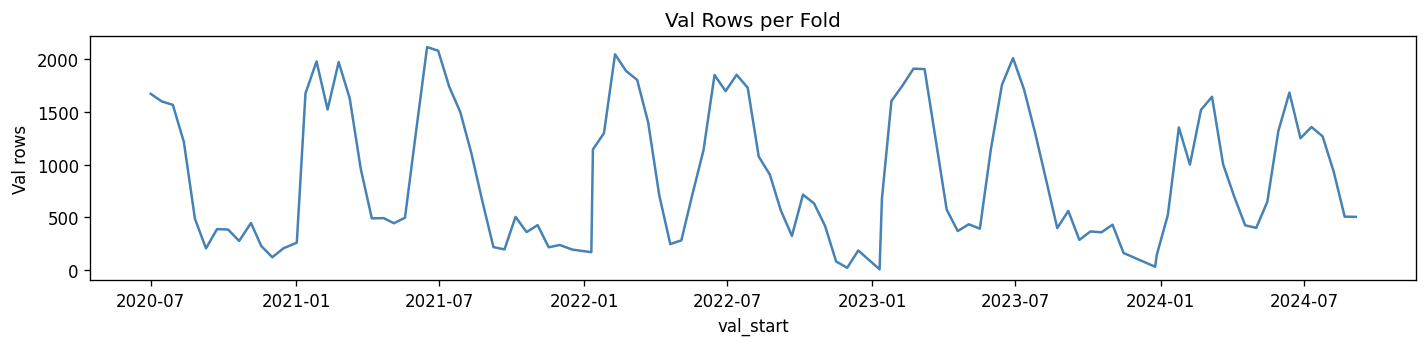

In [14]:
# Fold overview
fold_desc = describe_folds(dev_df, folds)
display(fold_desc.tail(10))

# Val size over time
fold_desc.plot(
    x='val_start', y='val_rows', figsize=(12, 3),
    title='Val Rows per Fold', legend=False, color='steelblue'
)
plt.ylabel('Val rows')
plt.tight_layout()
plt.show()

---
## 6. Rolling Cross-Validation

Runs all 5 models across all rolling folds.  
Preprocessing (imputer + scaler + OHE) is fitted **inside each fold** on training rows only.

**Note:** This takes ~30 min on all years × 246 folds. Use cached results if available.

In [15]:
from pipeline.models import run_cv, summarise_cv, MODEL_NAMES, BASELINE_METRICS
from pipeline.tuning import load_best_params

cv_path = OUTPUT_DIR / 'cv_results.csv'
cv_df = None

if not FORCE_CV and cv_path.exists():
    cv_df = pd.read_csv(cv_path)
    print(f'Loaded CV results from {cv_path.name} ({len(cv_df)} rows)')

if cv_df is None:
    # Load best params if available (won't affect first run)
    best_params = load_best_params() or {m: {} for m in MODEL_NAMES}
    
    t0 = time.time()
    cv_df = run_cv(dev_df, folds, num_cols, cat_cols, best_params)
    print(f'CV complete in {time.time()-t0:.1f}s')
    cv_df.to_csv(cv_path, index=False)
    print(f'Saved to {cv_path.name}')

Rolling CV — 109 folds × 5 models
  fold   1/109  [lasso=0.6091  ridge=0.6071  elasticnet=0.6088  logistic=0.6082  xgboost=0.6077]  elapsed=2s  eta=241s


17:34:31  INFO     CV progress: fold 1 / 109


  fold   2/109  [lasso=0.6008  ridge=0.5996  elasticnet=0.6006  logistic=0.6039  xgboost=0.6029]  elapsed=5s  eta=249s


17:34:34  INFO     CV progress: fold 2 / 109


  fold   3/109  [lasso=0.5943  ridge=0.5967  elasticnet=0.5946  logistic=0.5999  xgboost=0.5983]  elapsed=7s  eta=250s


...

  fold 108/109  [lasso=0.6557  ridge=0.6529  elasticnet=0.6547  logistic=0.6533  xgboost=0.6547]  elapsed=265s  eta=2s


17:38:54  INFO     CV progress: fold 108 / 109


  fold 109/109  [lasso=0.6752  ridge=0.6718  elasticnet=0.6753  logistic=0.6794  xgboost=0.6769]  elapsed=268s  eta=0s


17:38:57  INFO     CV progress: fold 109 / 109


CV complete in 268s
CV complete in 267.8s
Saved to cv_results.csv


In [16]:
# CV Summary table
summary = summarise_cv(cv_df)
print('CV Summary (mean ± std across folds):')
print()
display(summary)
print()
print('Baseline (predict 0.5 always):', BASELINE_METRICS)

CV Summary (mean ± std across folds):



log_loss             brier          accuracy         
               mean      std     mean      std     mean      std
model                                                           
elasticnet  0.64333  0.03360  0.22632  0.01533  0.62422  0.04595
lasso_lr    0.64317  0.03314  0.22625  0.01514  0.62476  0.04576
logistic    0.64804  0.03911  0.22813  0.01720  0.62411  0.04331
ridge_lr    0.64384  0.03482  0.22653  0.01581  0.62618  0.04530
xgboost     0.64530  0.03573  0.22733  0.01624  0.62399  0.04507


Baseline (predict 0.5 always): {'log_loss': 0.6931, 'brier': 0.25, 'accuracy': 0.5}


17:38:57  INFO     Saved /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/outputs/cv_log_loss.png


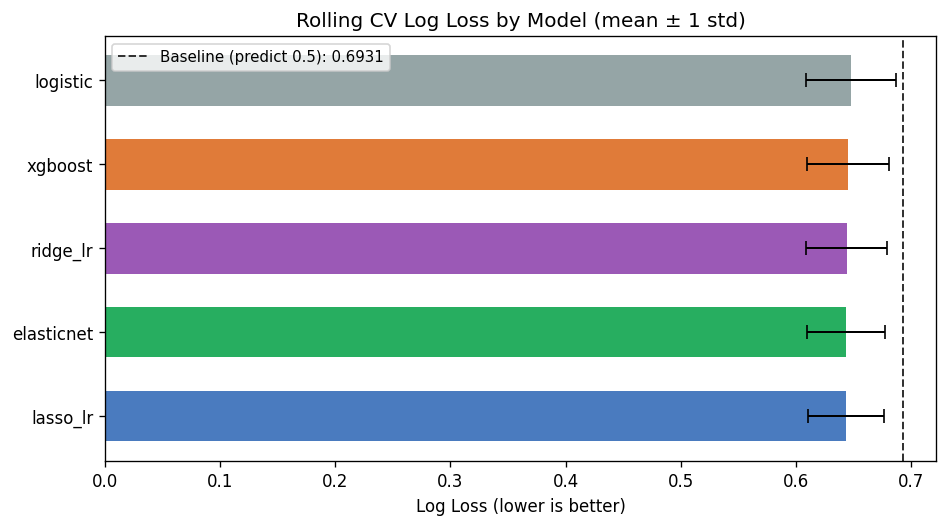

In [17]:
# CV Log-loss bar chart
from pipeline.evaluation import plot_cv_summary, plot_cv_metric_over_time
fig = plot_cv_summary(cv_df, save=True)
plt.show()

---
## 7. Hyperparameter Tuning

Random search over the param grids (defined in `pipeline/models.py`).  
Optimises `log_loss` on the most recent `TUNE_LAST_N_FOLDS` rolling folds.  
Results are cached to `cache/best_params.json` — set `FORCE_TUNE = True` to re-run.

In [18]:
import json
from pipeline.tuning import tune_all_models, load_best_params

best_params = tune_all_models(
    dev_df, folds, num_cols, cat_cols,
    n_iter=N_TUNE_ITER,
    last_n_folds=TUNE_LAST_N_FOLDS,
    force_retune=FORCE_TUNE,
)

print('\nBest hyperparameters:')
print(json.dumps(best_params, indent=2))

17:38:57  INFO     Tuning on 30 folds (last 30 of 109 total)
17:38:57  INFO     Tuning lasso_lr (20 iterations × 30 folds) ...



[lasso_lr] tuning 20 combos × 30 folds ...
  combo   1/20  loss=0.63582 *
  combo   2/20  loss=0.69315
  combo   3/20  loss=0.69315
  combo   4/20  loss=0.63680
  combo   5/20  loss=0.64702
  combo   6/20  loss=0.63808
  combo   7/20  loss=0.69315
  combo   8/20  loss=0.63749
  combo   9/20  loss=0.69315
  combo  10/20  loss=0.63325 *
  combo  11/20  loss=0.63649
  combo  12/20  loss=0.63311 *
  combo  13/20  loss=0.69315
  combo  14/20  loss=0.63429
  combo  15/20  loss=0.63256 *
  combo  16/20  loss=0.63617
  combo  17/20  loss=0.63337
  combo  18/20  loss=0.63312
  combo  19/20  loss=0.68905
  combo  20/20  loss=0.66600


17:41:58  INFO     lasso_lr         best log_loss=0.63256  params={'C': 0.015}


[lasso_lr] done — best log_loss=0.63256  params={'C': 0.015}


17:41:58  INFO     Tuning ridge_lr (20 iterations × 30 folds) ...


...


[xgboost] tuning 20 combos × 30 folds ...
  combo   1/20  loss=0.64981 *
  combo   2/20  loss=0.67827
  combo   3/20  loss=0.63476 *
  combo   4/20  loss=0.63950
  combo   5/20  loss=0.63434 *
  combo   6/20  loss=0.65676
  combo   7/20  loss=0.64027
  combo   8/20  loss=0.67974
  combo   9/20  loss=0.75763
  combo  10/20  loss=0.64417
  combo  11/20  loss=0.63662
  combo  12/20  loss=0.63647
  combo  13/20  loss=0.64005
  combo  14/20  loss=0.65807
  combo  15/20  loss=0.69249
  combo  16/20  loss=0.68945
  combo  17/20  loss=0.67082
  combo  18/20  loss=0.63359 *
  combo  19/20  loss=0.63403
  combo  20/20  loss=0.64433


18:13:19  INFO     xgboost          best log_loss=0.63359  params={'n_estimators': 750, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1, 'min_child_weight': 1, 'gamma': 0.1}


[xgboost] done — best log_loss=0.63359  params={'n_estimators': 750, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1, 'min_child_weight': 1, 'gamma': 0.1}


18:13:19  INFO     Saved best params to /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/cache/best_params.json



Best hyperparameters:
{
  "lasso_lr": {
    "C": 0.015
  },
  "ridge_lr": {
    "C": 0.0005
  },
  "elasticnet": {
    "C": 0.01,
    "l1_ratio": 0.6
  },
  "logistic": {},
  "xgboost": {
    "n_estimators": 750,
    "max_depth": 3,
    "learning_rate": 0.01,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_lambda": 1,
    "min_child_weight": 1,
    "gamma": 0.1
  }
}


---
## 8. Re-run CV with Tuned Parameters

Optional: re-run CV with best params to see the improvement. Skip if you already ran Stage 6 with tuned params loaded.

In [19]:
# Re-run CV on last 20 folds only (fast) with tuned params
print('CV on last 20 folds with tuned params...')
tuned_cv_df = run_cv(dev_df, folds[-20:], num_cols, cat_cols, best_params)

print('\nTuned CV Summary (last 20 folds):')
display(summarise_cv(tuned_cv_df))

CV on last 20 folds with tuned params...
Rolling CV — 20 folds × 5 models
  fold   1/20  [lasso=0.6658  ridge=0.6544  elasticnet=0.6706  logistic=0.6700  xgboost=0.6942]  elapsed=2s  eta=35s


18:13:21  INFO     CV progress: fold 1 / 20


  fold   2/20  [lasso=0.6527  ridge=0.6483  elasticnet=0.6535  logistic=0.6533  xgboost=0.6401]  elapsed=4s  eta=33s


18:13:23  INFO     CV progress: fold 2 / 20


  fold   3/20  [lasso=0.6418  ridge=0.6454  elasticnet=0.6418  logistic=0.6431  xgboost=0.6463]  elapsed=5s  eta=29s


...

18:13:56  INFO     CV progress: fold 19 / 20


  fold  20/20  [lasso=0.6752  ridge=0.6718  elasticnet=0.6753  logistic=0.6794  xgboost=0.6775]  elapsed=39s  eta=0s


18:13:58  INFO     CV progress: fold 20 / 20


CV complete in 39s

Tuned CV Summary (last 20 folds):


log_loss             brier          accuracy         
               mean      std     mean      std     mean      std
model                                                           
elasticnet  0.63143  0.03106  0.22111  0.01373  0.63787  0.03912
lasso_lr    0.63128  0.03067  0.22103  0.01356  0.63900  0.03896
logistic    0.63508  0.03184  0.22269  0.01404  0.63701  0.03729
ridge_lr    0.63005  0.03013  0.22061  0.01332  0.64075  0.03655
xgboost     0.63237  0.03403  0.22175  0.01493  0.63781  0.03480

---
## 9. Final Holdout Evaluation

**This cell touches the holdout set for the first time.**  
Retrains each model on the full development set, evaluates once on the held-out 20%.

Do not run this until all design choices (features, models, hyperparams) are fixed.

In [20]:
from pipeline.evaluation import (
    evaluate_on_holdout, holdout_summary_df,
    plot_calibration, plot_feature_importance,
)

holdout_results = evaluate_on_holdout(
    dev_df, hold_df, num_cols, cat_cols, best_params
)

summary_df = holdout_summary_df(holdout_results)
summary_df.to_csv(OUTPUT_DIR / 'holdout_results.csv')

print('Holdout Results:')
display(summary_df)

18:14:00  INFO     Holdout lasso_lr         log_loss=0.63310  brier=0.22174  acc=0.6333
18:14:01  INFO     Holdout ridge_lr         log_loss=0.63318  brier=0.22176  acc=0.6340
18:14:11  INFO     Holdout elasticnet       log_loss=0.63299  brier=0.22170  acc=0.6332
18:14:12  INFO     Holdout logistic         log_loss=0.63336  brier=0.22185  acc=0.6353
18:14:20  INFO     Holdout xgboost          log_loss=0.62970  brier=0.22027  acc=0.6374


Holdout Results:


,log_loss,brier,accuracy
model,,,
lasso_lr,0.63310,0.22174,0.63334
ridge_lr,0.63318,0.22176,0.63395
elasticnet,0.63299,0.22170,0.63316
logistic,0.63336,0.22185,0.63525
xgboost,0.62970,0.22027,0.63737
baseline,0.69310,0.25000,0.50000


In [21]:
# ── Save ALL model bundles for production inference ────────────────────────
# Trains every model in MODEL_REGISTRY on the full dev set and saves a bundle
# for each. The app loads all of them to compare predictions side-by-side.

import pickle
from sklearn.base import clone
from pipeline.models import MODEL_REGISTRY, make_preprocessor

pre       = make_preprocessor(num_cols, cat_cols)
X_dev_fit = pre.fit_transform(dev_df[num_cols + cat_cols])
y_dev_fit = dev_df['result'].values

# Also save feat_df for inference (team rolling stats lookup) — done once
feat_df.to_pickle(CACHE_DIR / 'feat_df_for_inference.pkl')
print(f'feat_df saved → cache/feat_df_for_inference.pkl')
print()

from sklearn.metrics import log_loss

for model_key, (base_est, _) in MODEL_REGISTRY.items():
    est    = clone(base_est)
    params = best_params.get(model_key, {})
    if params:
        est.set_params(**params)
    est.fit(X_dev_fit, y_dev_fit)

    bundle = {
        'model_name':   model_key,
        'preprocessor': pre,
        'classifier':   est,
        'num_cols':     num_cols,
        'cat_cols':     cat_cols,
    }
    path = CACHE_DIR / f'model_bundle_{model_key}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(bundle, f)

    X_hold_check = pre.transform(hold_df[num_cols + cat_cols])
    y_prob_check = est.predict_proba(X_hold_check)[:, 1]
    ll = log_loss(hold_df['result'].values, y_prob_check)
    print(f'  {model_key:<15}  holdout log-loss: {ll:.5f}  → {path.name}')

# Also keep a single default bundle (best model based on holdout)
PRODUCTION_MODEL = 'ridge_lr'
best_path = CACHE_DIR / f'model_bundle_{PRODUCTION_MODEL}.pkl'
import shutil
shutil.copy(best_path, CACHE_DIR / 'model_bundle.pkl')
print(f'\nDefault bundle (model_bundle.pkl) = {PRODUCTION_MODEL}')


feat_df saved → cache/feat_df_for_inference.pkl

  lasso_lr         holdout log-loss: 0.63310  → model_bundle_lasso_lr.pkl
  ridge_lr         holdout log-loss: 0.63318  → model_bundle_ridge_lr.pkl
  elasticnet       holdout log-loss: 0.63299  → model_bundle_elasticnet.pkl
  logistic         holdout log-loss: 0.63336  → model_bundle_logistic.pkl
  xgboost          holdout log-loss: 0.62970  → model_bundle_xgboost.pkl

Default bundle (model_bundle.pkl) = ridge_lr


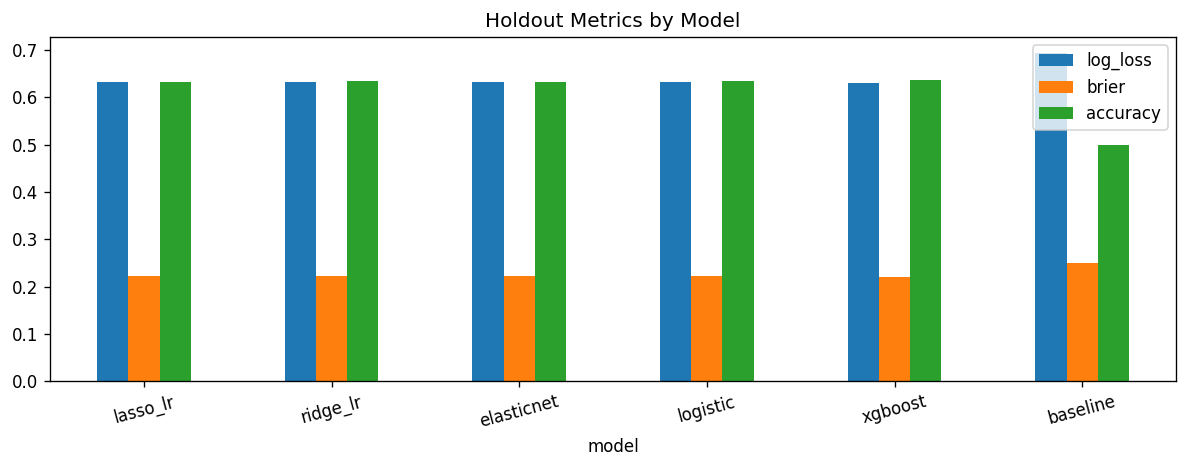

In [22]:
# Holdout bar chart
ax = summary_df[['log_loss', 'brier', 'accuracy']].plot(
    kind='bar', figsize=(10, 4), title='Holdout Metrics by Model',
    subplots=False, rot=15
)
plt.tight_layout()
plt.show()

18:14:42  INFO     Saved /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/outputs/calibration.png


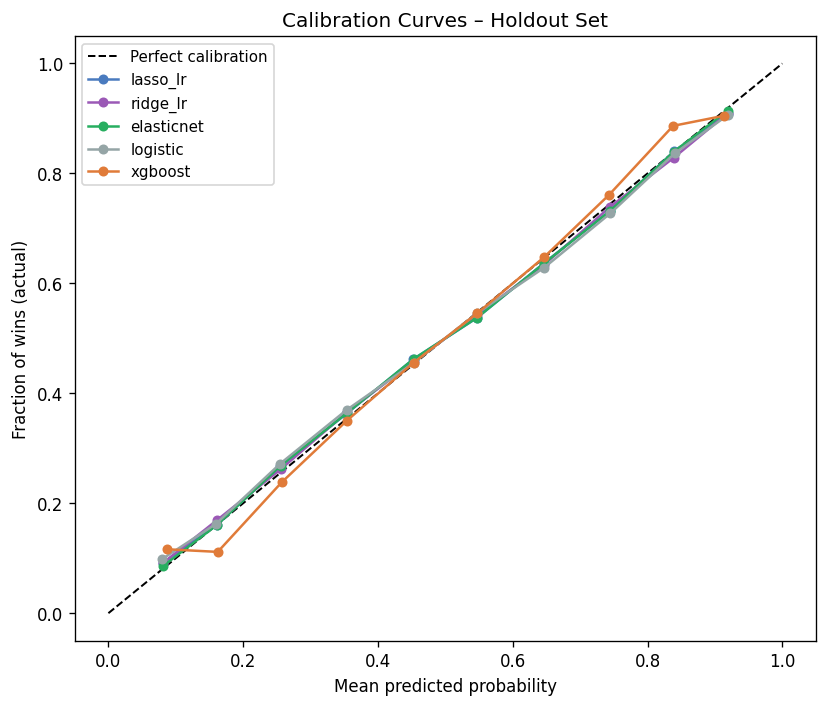

In [23]:
# Calibration curves
fig = plot_calibration(holdout_results, save=True)
plt.show()

---
## 10. Feature Importance & Ablation Study

18:14:50  INFO     Saved /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/outputs/feature_importance.png


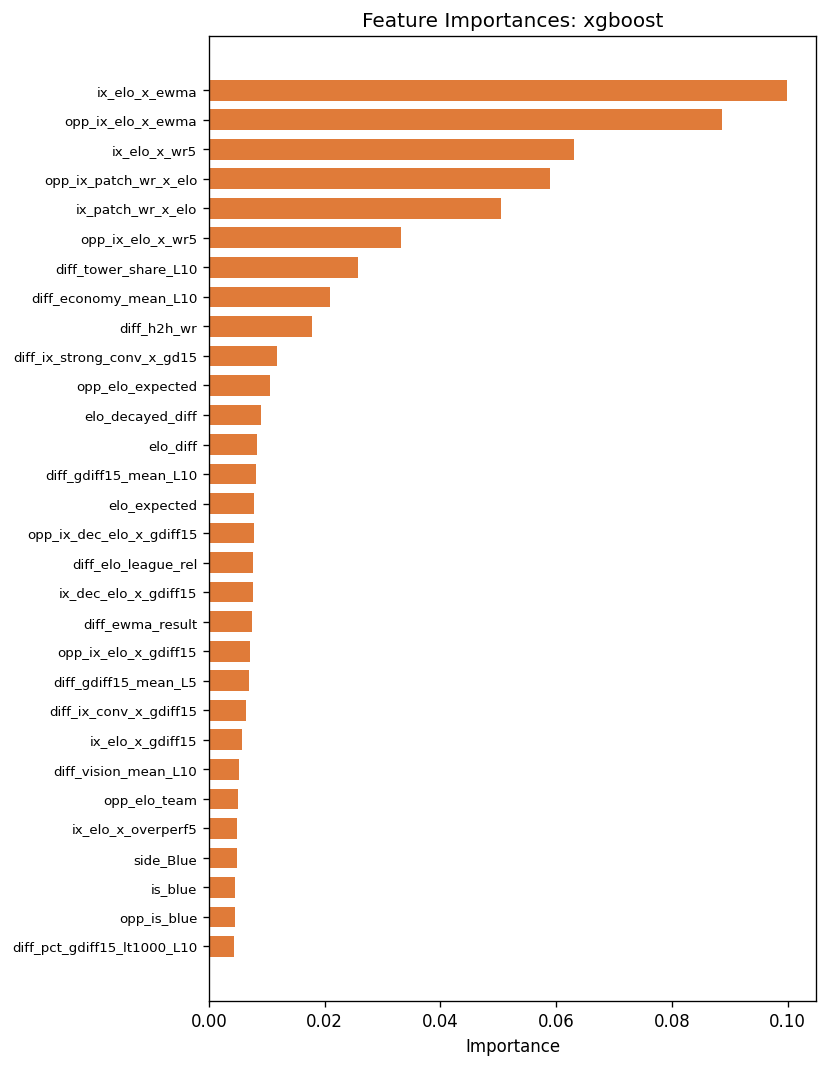

In [24]:
# Feature importances (XGBoost and Random Forest)
fig = plot_feature_importance(dev_df, num_cols, cat_cols, best_params, top_n=30, save=True)
plt.show()

In [25]:
# Lasso logistic regression: non-zero coefficients (implicit feature selection)
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from pipeline.models import MODEL_REGISTRY, make_preprocessor

pre = make_preprocessor(num_cols, cat_cols)
X_dev = pre.fit_transform(dev_df[num_cols + cat_cols])
y_dev = dev_df['result'].values

estimator, _ = MODEL_REGISTRY['lasso_lr']
lasso = clone(estimator)
params = best_params.get('lasso_lr', {})
if params:
    lasso.set_params(**params)
lasso.fit(X_dev, y_dev)

# Get feature names
try:
    num_names = list(pre.named_transformers_['num'].get_feature_names_out(num_cols))
    cat_names = list(pre.named_transformers_['cat'].get_feature_names_out())
    feature_names = num_names + cat_names
except (KeyError, AttributeError):
    feature_names = [f'f{i}' for i in range(X_dev.shape[1])]

coef = lasso.coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df = coef_df[coef_df['coef'] != 0].sort_values('coef', key=abs, ascending=False)

print(f'Lasso non-zero coefficients: {len(coef_df)} / {len(feature_names)}')
display(coef_df.head(30))

Lasso non-zero coefficients: 69 / 511


,feature,coef
252,diff_economy_mean_L10,0.239173
271,diff_ix_opp_elo_x_wr10,-0.173257
246,diff_tower_share_L10,0.164415
254,diff_gamelength_mean_L10,-0.129818
199,diff_avg_opp_elo_L10,0.126712
259,diff_patch_wr_shrunk,0.125106
6,elo_decayed_diff,0.120364
72,is_blue,0.106971
251,diff_vision_mean_L10,0.106119
250,diff_pace_mean_L10,-0.101018


In [26]:
# ── Full ablation study ─────────────────────────────────────────────────────
# Compares cumulative feature groups: tells you which groups add real signal.
# Uses last 30 rolling folds and Ridge LR with tuned params for accuracy.
from pipeline.evaluation import run_ablation

abl_path = OUTPUT_DIR / 'ablation_results.csv'
abl_df = None

if abl_path.exists() and not FORCE_ABLATION:
    abl_df = pd.read_csv(abl_path)
    print(f'Loaded ablation results from {abl_path.name}')

if abl_df is None:
    abl_df = run_ablation(dev_df, folds, num_cols, cat_cols, best_params=best_params)
    abl_df.to_csv(abl_path, index=False)

display(abl_df)

Ablation study — 10 sets × 30 folds (ridge_lr)
  Using tuned params: {'C': 0.0005}
  [1/10] A_elo_only                    features= 39  logloss=0.64092 ± 0.02377  (1s elapsed)


18:14:53  INFO     Ablation A_elo_only            features= 39  logloss=0.64092 ± 0.02377


  [2/10] A+B                           features= 75  logloss=0.63773 ± 0.02427  (1s elapsed)


18:14:54  INFO     Ablation A+B                   features= 75  logloss=0.63773 ± 0.02427


  [3/10] A+B+C                         features=183  logloss=0.63616 ± 0.02742  (2s elapsed)


...

18:15:01  INFO     Ablation Tier1+2+interactions  features=231  logloss=0.63445 ± 0.02803


  [10/10] Full                          features=246  logloss=0.63430 ± 0.02808  (10s elapsed)


18:15:03  INFO     Ablation Full                  features=246  logloss=0.63430 ± 0.02808


Ablation complete in 10s


,ablation,n_features,mean_logloss,std_logloss
0,A_elo_only,39,0.640919,0.023767
1,A+B,75,0.637732,0.024272
2,A+B+C,183,0.636160,0.027418
3,A+B+C+thresholds,183,0.636160,0.027418
4,Tier1,192,0.636384,0.027712
5,Tier1+thresholds,192,0.636384,0.027712
6,Tier1+2_no_style,225,0.634534,0.028092
7,Tier1+2_with_style,240,0.634340,0.028096
8,Tier1+2+interactions,231,0.634451,0.028027
9,Full,246,0.634298,0.028082


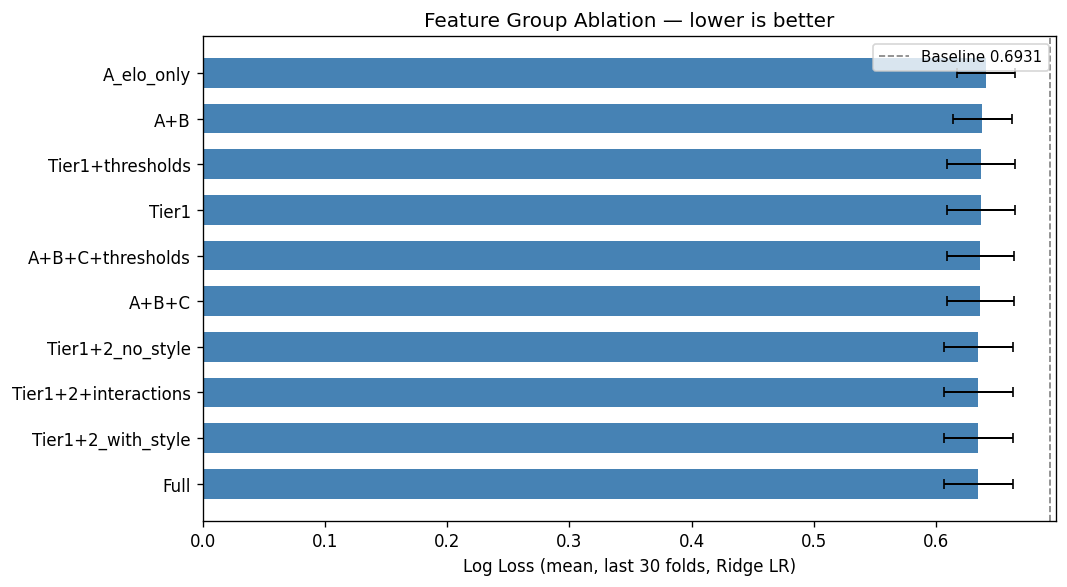

In [27]:
# ── Ablation chart ──────────────────────────────────────────────────────────
if abl_df is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    abl_sorted = abl_df.sort_values('mean_logloss')
    bars = ax.barh(
        abl_sorted['ablation'], abl_sorted['mean_logloss'],
        xerr=abl_sorted['std_logloss'], color='steelblue', height=0.65,
        error_kw={'capsize': 3, 'elinewidth': 1.2},
    )
    ax.axvline(BASELINE_METRICS['log_loss'], color='gray', ls='--', lw=1, label=f'Baseline {BASELINE_METRICS["log_loss"]:.4f}')
    ax.set_xlabel('Log Loss (mean, last 30 folds, Ridge LR)')
    ax.set_title('Feature Group Ablation — lower is better')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'ablation_chart.png', dpi=150)
    plt.show()

### 10b. Targeted comparisons: style features and interactions

These answer the two key questions from the analysis:
1. Do style features (Group F) add signal or hurt generalisation?
2. Do explicit interaction terms add signal beyond the base features?

In [28]:
from pipeline.evaluation import ABLATION_GROUPS, ABLATION_SETS
from pipeline.models import train_eval_fold, make_preprocessor, BASELINE_METRICS
from sklearn.base import clone
import numpy as np

def run_targeted_comparison(label_a, cols_a, label_b, cols_b,
                            model_name='ridge_lr', n_folds=20):
    """Compare two feature sets on the last n_folds, return summary."""
    test_folds = folds[-n_folds:]
    results = {label_a: [], label_b: []}

    for cols, label in [(cols_a, label_a), (cols_b, label_b)]:
        num_c = [c for c in cols if c in num_cols]
        cat_c = [c for c in cat_cols if c in ds_df.columns]
        for tr_idx, val_idx in test_folds:
            tr  = dev_df.loc[tr_idx]
            val = dev_df.loc[val_idx]
            pre = make_preprocessor(num_c, cat_c)
            X_tr  = pre.fit_transform(tr[num_c + cat_c])
            X_val = pre.transform(val[num_c + cat_c])
            m = train_eval_fold(model_name, X_tr, tr['result'].values,
                                X_val, val['result'].values)
            results[label].append(m['log_loss'])

    for label, losses in results.items():
        print(f'{label:40s}  logloss={np.mean(losses):.5f} ± {np.std(losses):.5f}')
    delta = np.mean(results[label_b]) - np.mean(results[label_a])
    print(f'  Δ ({label_b} vs {label_a}): {delta:+.5f}  (negative = B is better)')
    return results


# ── Test 1: with vs without style features (Group F) ───────────────────────
style_feat_names = ['pace_mean_L10', 'vision_mean_L10', 'economy_mean_L10',
                    'aggression_mean_L10', 'gamelength_mean_L10']

# Build both col sets (include opp_ and diff_ versions automatically)
no_style  = [c for c in num_cols if not any(s in c for s in style_feat_names)]
with_style = num_cols  # current full set

print('=== Style Features (Group F) ===')
run_targeted_comparison('without_style', no_style, 'with_style', with_style)

=== Style Features (Group F) ===
without_style                             logloss=0.63678 ± 0.03120
with_style                                logloss=0.63476 ± 0.03076
  Δ (with_style vs without_style): -0.00202  (negative = B is better)


{'without_style': [0.6581971311687552,
  0.6669628985766697,
  0.6600465744238062,
  0.6359437050583777,
  0.6388358435875092,
  0.6071664887104417,
  0.6311908176434642,
  0.6735843710287802,
  0.6545711826238679,
  0.6673660262891091,
  0.6412049941172514,
  0.6533926686812959,
  0.5953550795949861,
  0.5640804240281588,
  0.5726151501205959,
  0.6123723300861564,
  0.6424424034419813,
  0.6268400654562986,
  0.6590917568375907,
  0.6742476232840248],
 'with_style': [0.6700705889797415,
  0.6562074178862819,
  0.6465238578058413,
  0.6285735546256149,
  0.6311757441174884,
  0.6037439894142772,
  0.6326767166320502,
  0.6722047029658269,
  0.6449222090638023,
  0.6680165979928067,
  0.6402790871548905,
  0.651859507691921,
  0.5960091616554112,
  0.562490571965153,
  0.5767160599517439,
  0.6110178636558313,
  0.643400792251969,
  0.626626083619116,
  0.6532467022403701,
  0.6793525193495401]}

In [29]:
# ── Test 2: with vs without interaction features (Group K) ──────────────────
no_interact   = [c for c in num_cols if not c.startswith('ix_')]
with_interact = num_cols

print('=== Interaction Features (Group K) ===')
run_targeted_comparison('without_interactions', no_interact, 'with_interactions', with_interact)

print()
# ── Test 3: with vs without threshold features (C_thresholds) ───────────────
thresh_names = ['pct_gdiff15_gt', 'pct_gdiff15_lt', 'pct_gdiff10_gt', 'pct_gdiff10_lt']
no_thresh   = [c for c in num_cols if not any(c.startswith(t) or 
                                               c.replace('opp_','').replace('diff_','').startswith(t)
                                               for t in thresh_names)]
with_thresh = num_cols

print('=== Threshold Features (C_thresholds) ===')
run_targeted_comparison('without_thresholds', no_thresh, 'with_thresholds', with_thresh)

print()
# ── Test 4: with vs without decayed Elo ─────────────────────────────────────
dec_elo_names = ['elo_decayed_team', 'elo_decayed_opp', 'elo_decayed_diff', 'ix_dec_elo']
no_dec_elo   = [c for c in num_cols if not any(c.startswith(d) for d in dec_elo_names)]
with_dec_elo = num_cols

print('=== Decayed Elo ===')
run_targeted_comparison('without_decayed_elo', no_dec_elo, 'with_decayed_elo', with_dec_elo)

=== Interaction Features (Group K) ===
without_interactions                      logloss=0.63440 ± 0.03059
with_interactions                         logloss=0.63476 ± 0.03076
  Δ (with_interactions vs without_interactions): +0.00036  (negative = B is better)

=== Threshold Features (C_thresholds) ===
without_thresholds                        logloss=0.63530 ± 0.03178
with_thresholds                           logloss=0.63476 ± 0.03076
  Δ (with_thresholds vs without_thresholds): -0.00055  (negative = B is better)

=== Decayed Elo ===
without_decayed_elo                       logloss=0.63514 ± 0.03107
with_decayed_elo                          logloss=0.63476 ± 0.03076
  Δ (with_decayed_elo vs without_decayed_elo): -0.00038  (negative = B is better)


{'without_decayed_elo': [0.6686524804951954,
  0.6549192373000465,
  0.6455643366895649,
  0.6290101160268445,
  0.6314779682171252,
  0.60282519393257,
  0.6331983453222366,
  0.6725384127704107,
  0.6449201882145508,
  0.6696179883905503,
  0.6395069119123454,
  0.6604724680639902,
  0.596136984691669,
  0.5629792712677177,
  0.5763553993267095,
  0.6110054282796105,
  0.6433231937171181,
  0.6268112184016353,
  0.653700204645299,
  0.6797593242178954],
 'with_decayed_elo': [0.6700705889797415,
  0.6562074178862819,
  0.6465238578058413,
  0.6285735546256149,
  0.6311757441174884,
  0.6037439894142772,
  0.6326767166320502,
  0.6722047029658269,
  0.6449222090638023,
  0.6680165979928067,
  0.6402790871548905,
  0.651859507691921,
  0.5960091616554112,
  0.562490571965153,
  0.5767160599517439,
  0.6110178636558313,
  0.643400792251969,
  0.626626083619116,
  0.6532467022403701,
  0.6793525193495401]}

---
## 11. Leakage Checklist

In [30]:
from pipeline.evaluation import leakage_report
leakage_report(ds_df, num_cols)

18:15:12  INFO     ============================================================
18:15:12  INFO     LEAKAGE CHECKLIST
18:15:12  INFO     ============================================================
18:15:12  INFO       [PASS]  No draft columns  |  OK
18:15:12  INFO       [PASS]  No same-match realised stats  |  OK
18:15:12  INFO       [PASS]  No raw at-time snapshots  |  OK
18:15:12  INFO       [PASS]  opp_ features are rolling (not same-match)  |  OK – built in dataset.py
18:15:12  INFO       [PASS]  gamelength not used as direct feature  |  OK – only gamelength_mean_L10 (lagged)
18:15:12  INFO     ============================================================
18:15:12  INFO     All leakage checks passed.


In [31]:
# Manual spot-checks
# Pick a random team and verify their features at a given match are consistent
# with a manual calculation from their prior match history

import random
random.seed(42)

team_name = 'T1'   # change to any team
team_rows = ds_df[ds_df['teamname'] == team_name].sort_values('date')

if team_rows.empty:
    print(f'{team_name} not found. Available teams (sample):', ds_df['teamname'].dropna().unique()[:10].tolist())
else:
    # Pick the 20th match (enough history to check rolling features)
    idx = min(20, len(team_rows) - 1)
    row = team_rows.iloc[idx]
    prior = team_rows.iloc[:idx]

    print(f'Team: {team_name}')
    print(f'Match date: {row["date"].date()}')
    print(f'Prior matches used: {len(prior)}')
    print()

    # Manual check: wr_L5
    manual_wr5 = prior['result'].tail(5).mean()
    print(f'wr_L5  — pipeline: {row["wr_L5"]:.4f}  manual: {manual_wr5:.4f}  match: {abs(row["wr_L5"] - manual_wr5) < 0.001}')

    # Manual check: gdiff15_mean_L10 (may be 0 for early matches with no data)
    if 'gdiff15_mean_L5' in ds_df.columns:
        # Can't recompute here (raw data dropped), but we can verify range is sensible
        print(f'gdiff15_mean_L5 — pipeline: {row.get("gdiff15_mean_L5", "N/A")}  (sensible range: -3000 to 3000)')

    # Elo should be > 1500 if this team is good
    print(f'elo_team — {row["elo_team"]:.1f}')

Team: T1
Match date: 2020-02-26
Prior matches used: 20

wr_L5  — pipeline: 0.8000  manual: 0.8000  match: True
gdiff15_mean_L5 — pipeline: -1205.0  (sensible range: -3000 to 3000)
elo_team — 1544.1


---
## 12. Output Files

All outputs are saved to `./outputs/`:

In [32]:
print('Output files:')
for p in sorted(OUTPUT_DIR.iterdir()):
    size = p.stat().st_size
    print(f'  {p.name:<35}  {size/1024:.1f} KB')

Output files:
  ablation_chart.png                   47.4 KB
  ablation_results.csv                 0.6 KB
  calibration.png                      79.6 KB
  cv_log_loss.png                      35.7 KB
  cv_log_loss_over_time.png            138.1 KB
  cv_results.csv                       36.7 KB
  draft                                0.2 KB
  feature_importance.png               88.3 KB
  holdout_results.csv                  0.2 KB
  pipeline.log                         5.3 KB
  run.log                              838.1 KB


---
## 13. Betting & Market-Making Analysis

Designed for **Polymarket pre-draft match markets** that resolve in 1+ week.
You act as a retail market maker: post bid/ask orders around your fair value,
earn maker rebates + liquidity rewards, and take directional positions when edge is large.

**Two income streams:**
1. **Maker rebates**: 25% of taker fee collected when your resting order is taken.
2. **Liquidity Rewards**: $1,550/game pre-period (A/B tier: LCK/LPL/LEC/LCS). Distributed
   pro-rata by quadratic spread-weighted score. Often dominates over directional PnL.

**Fee structure (Sports/Esports):**
- Taker fee: `0.03 × p × (1 − p)` per share — **75 bps at p=0.50, 63 bps at p=0.30/0.70**
- Maker fee: **ZERO** (makers are never charged)
- Maker rebate: **25% of taker fee** (~19 bps per share at p=0.50)

**Liquidity reward score:** `S(v, s) = ((v − s) / v)² × size`
where v = max qualifying spread (default 3 cents), s = your spread from mid.
Two-sided quotes earn `Q_min = min(Q_bid, Q_ask)` — **always quote both sides**.


In [33]:
from pipeline.betting import (
    compute_edge, kelly_fraction, market_maker_quotes,
    simulate_market_making, generate_quotes, QuoteParams, fee_table,
    taker_fee_per_share, maker_rebate_per_share,
)

# ── Fee structure at a glance ──────────────────────────────────────────────
print('Polymarket Sports/Esports fee curve:')
display(fee_table())
print()

# ── Quote parameters ───────────────────────────────────────────────────────
QUOTE_PARAMS = QuoteParams(
    half_spread    = 0.03,   # 3 cents each side (6-cent wide market)
    min_edge       = 0.02,   # post directional bet only when |model − market| > 2%
    inventory_skew = 0.0,    # neutral (adjust as you accumulate inventory)
    max_inventory  = 0.05,   # max 5% of bankroll per directional position
    kelly_frac     = 0.25,   # quarter-Kelly for conservative sizing
)

# ── Quick demo: single match ────────────────────────────────────────────────
print('Example quotes for a single match:')
print()
for p_model, p_market, label in [
    (0.62, 0.55, 'Strong edge — market undervalues favourite'),
    (0.52, 0.50, 'Weak edge — near 50/50 market'),
    (0.48, 0.55, 'Negative edge — model prefers underdog'),
    (0.65, 0.63, 'Small edge — model slightly higher than market'),
]:
    q    = market_maker_quotes(p_model, p_market, QUOTE_PARAMS)
    fee  = taker_fee_per_share(p_market)
    rebate = maker_rebate_per_share(p_market)
    print(f'  [{label}]')
    print(f'    Model={p_model:.3f}  Market={p_market:.3f}  Edge={q.edge:+.3f}')
    print(f'    TakerFee={fee:.4f}  MakerRebate={rebate:.5f}  NetTakerEdge={q.net_taker_edge:+.4f}')
    print(f'    Bid={q.bid:.2f}  Ask={q.ask:.2f}  Direction={q.bet_direction}  Kelly={q.kelly_size:.3f}')
    print()


Polymarket Sports/Esports fee curve:


,price,taker_fee,taker_fee_bps,maker_rebate,maker_rebate_bps,min_edge_to_bet
0,0.1,0.0027,27.0,0.000675,6.8,0.0027
1,0.2,0.0048,48.0,0.001200,12.0,0.0048
2,0.3,0.0063,63.0,0.001575,15.7,0.0063
3,0.4,0.0072,72.0,0.001800,18.0,0.0072
4,0.5,0.0075,75.0,0.001875,18.8,0.0075
5,0.6,0.0072,72.0,0.001800,18.0,0.0072
6,0.7,0.0063,63.0,0.001575,15.8,0.0063
7,0.8,0.0048,48.0,0.001200,12.0,0.0048
8,0.9,0.0027,27.0,0.000675,6.7,0.0027



Example quotes for a single match:

  [Strong edge — market undervalues favourite]
    Model=0.620  Market=0.550  Edge=+0.070
    TakerFee=0.0074  MakerRebate=0.00186  NetTakerEdge=+0.0626
    Bid=0.55  Ask=0.61  Direction=YES  Kelly=0.035

  [Weak edge — near 50/50 market]
    Model=0.520  Market=0.500  Edge=+0.020
    TakerFee=0.0075  MakerRebate=0.00187  NetTakerEdge=+0.0125
    Bid=0.47  Ask=0.53  Direction=YES  Kelly=0.006

  [Negative edge — model prefers underdog]
    Model=0.480  Market=0.550  Edge=-0.070
    TakerFee=0.0074  MakerRebate=0.00186  NetTakerEdge=+0.0626
    Bid=0.49  Ask=0.55  Direction=NO  Kelly=0.029

  [Small edge — model slightly higher than market]
    Model=0.650  Market=0.630  Edge=+0.020
    TakerFee=0.0070  MakerRebate=0.00175  NetTakerEdge=+0.0130
    Bid=0.60  Ask=0.66  Direction=YES  Kelly=0.009



In [34]:
# ── Backtest: simulate market-making on holdout ─────────────────────────────
# We don't have real Polymarket prices for historical games, so we simulate
# market prices as: Elo-only model prediction + Gaussian noise (±5%).
# This approximates a market that knows Elo but not form/early-game info.
# Real edge will differ depending on how informationally efficient actual markets are.

import numpy as np
from sklearn.base import clone
from pipeline.models import MODEL_REGISTRY, make_preprocessor

np.random.seed(42)

# Get full model predictions
best_model = 'elasticnet'
pre = make_preprocessor(num_cols, cat_cols)
X_dev_  = pre.fit_transform(dev_df[num_cols + cat_cols])
X_hold_ = pre.transform(hold_df[num_cols + cat_cols])
est, _  = MODEL_REGISTRY[best_model]
m = clone(est); m.set_params(**best_params[best_model])
m.fit(X_dev_, dev_df['result'].values)
model_probs = pd.Series(m.predict_proba(X_hold_)[:,1], index=hold_df.index)

# Simulate market prices: Elo-only model + noise
elo_cols_ = [c for c in num_cols if 'elo' in c.lower() and not c.startswith('ix_')]
pre2 = make_preprocessor(elo_cols_, cat_cols)
X_dev2_  = pre2.fit_transform(dev_df[elo_cols_ + cat_cols])
X_hold2_ = pre2.transform(hold_df[elo_cols_ + cat_cols])
est2, _  = MODEL_REGISTRY['ridge_lr']
m2 = clone(est2); m2.set_params(**best_params['ridge_lr'])
m2.fit(X_dev2_, dev_df['result'].values)
elo_probs = m2.predict_proba(X_hold2_)[:,1]
noise = np.random.normal(0, 0.02, len(hold_df))   # ±2% market noise
market_prices = pd.Series(np.clip(elo_probs + noise, 0.05, 0.95), index=hold_df.index)

# Only use one row per game (avoid double-counting mirrored rows)
unique_game_mask = hold_df['result'] == 1
model_probs_u  = model_probs[unique_game_mask]
market_prices_u = market_prices[unique_game_mask]
results_u       = hold_df.loc[unique_game_mask, 'result']

print(f'Holdout unique games: {len(model_probs_u):,}')
print(f'Mean model prob: {model_probs_u.mean():.4f}')
print(f'Mean market price: {market_prices_u.mean():.4f}')
print(f'Mean edge: {(model_probs_u - market_prices_u).abs().mean():.4f}')
print()

Holdout unique games: 13,889
Mean model prob: 0.5590
Mean market price: 0.5507
Mean edge: 0.0582



In [35]:
# ── Run backtest across different edge thresholds ──────────────────────────
print('Backtest vs min_edge threshold — LoL A/B tier, 10% estimated liquidity share')
print(f'{"min_edge":<10} {"bets":<8} {"win_rate":<10} {"dir_pnl":<12} {"liq_reward":<14} {"total_pnl":<12} {"ROI":<8}')
print('-' * 76)

for min_edge in [0.01, 0.02, 0.03, 0.05, 0.07, 0.10]:
    p = QuoteParams(
        half_spread=0.03,
        min_edge=min_edge,
        max_inventory=0.05,
        kelly_frac=0.25,
    )
    sim = simulate_market_making(
        model_probs_u, market_prices_u, results_u,
        bankroll=1000.0, params=p, tier='AB', market_share=0.10,
    )
    if len(sim) > 0:
        wr   = (sim['directional_pnl'] > 0).mean()
        dpnl = sim['directional_pnl'].sum()
        liq  = sim['liquidity_reward'].sum()
        tpnl = sim['total_pnl'].sum()
        roi  = tpnl / 1000.0
        bets = (sim['bet_direction'] != 'PASS').sum()
        print(f'{min_edge:<10.2f} {bets:<8} {wr:<10.1%} {dpnl:<+12.2f} {liq:<+14.2f} {tpnl:<+12.2f} {roi:<8.2%}')
    else:
        print(f'{min_edge:<10.2f} {0:<8} {"—":<10} {"—":<12} {"—":<14} {"—":<12} {"—":<8}')


Backtest vs min_edge threshold — LoL A/B tier, 10% estimated liquidity share
min_edge   bets     win_rate   dir_pnl      liq_reward     total_pnl    ROI     
----------------------------------------------------------------------------

  Betting simulation summary
  Games processed:     13889
  Directional bets:    12185  (88% of games)
  Win rate (dir bets):  49.2%
  Directional P&L:   +1216933587048894.50 USDC
  Liquidity rewards: +2078085.00 USDC  (10% est. share, AB tier)
  Total P&L:         +1216933589126979.50 USDC
  ROI:               +121693358912697.95%
  Avg taker fee:       0.00669  (vs old flat 0.00050)
  Final bankroll:    1216933589127980.75 USDC
0.01       12185    49.2%      +1216933587048894.50 +2078085.00    +1216933589126979.50 121693358912697.95%

  Betting simulation summary
  Games processed:     13889
  Directional bets:    10526  (76% of games)
  Win rate (dir bets):  42.9%
  Directional P&L:   +1070113919126642.62 USDC
  Liquidity rewards: +2078085.00 USDC  (1

In [36]:
# ── Generate quotes for upcoming matches ─────────────────────────────────────
# Replace the example predictions and market_prices below with real data.
# market_prices come from the Polymarket API (current order book mid price).

print('Example: generate quotes for a batch of upcoming matches')
print('(Replace example_predictions and example_market_prices with real data)')
print()

# ── How to get Polymarket prices (Python snippet) ───────────────────────────
# from py_clob_client.client import ClobClient
# client = ClobClient(host='https://clob.polymarket.com', key=API_KEY, chain_id=137)
# book = client.get_order_book(token_id=TOKEN_ID)
# mid_price = (float(book.bids[0].price) + float(book.asks[0].price)) / 2

# ── Example with hypothetical upcoming matches ───────────────────────────────
example_matches = pd.DataFrame({
    'match':        ['T1 vs GenG', 'BLG vs JDG', 'Cloud9 vs TL', 'Fnatic vs G2'],
    'model_prob':   [0.64,          0.58,          0.52,           0.71],
    'market_price': [0.55,          0.54,          0.50,           0.68],
}).set_index('match')

quotes = generate_quotes(
    example_matches['model_prob'],
    example_matches['market_price'],
    QUOTE_PARAMS,
)

print('Recommended quotes (sorted by |edge|):')
display(quotes[['model_prob','market_price','edge','bid','ask','bet_direction','kelly_size']]
        .style.format(precision=3)
        .background_gradient(subset=['edge'], cmap='RdYlGn', vmin=-0.1, vmax=0.1))

Example: generate quotes for a batch of upcoming matches
(Replace example_predictions and example_market_prices with real data)

Recommended quotes (sorted by |edge|):


,model_prob,market_price,edge,bid,ask,bet_direction,kelly_size
0,0.640,0.550,0.090,0.550,0.620,YES,0.047
1,0.580,0.540,0.040,0.530,0.590,YES,0.018
2,0.710,0.680,0.030,0.660,0.720,YES,0.019
3,0.520,0.500,0.020,0.470,0.530,YES,0.006
